<a href="https://colab.research.google.com/github/Rakshithbodakuntla/ML_/blob/main/Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('CarPrice_Assignment.csv')

In [4]:
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [5]:
df.isnull().sum()

,0
car_ID,0
symboling,0
CarName,0
fueltype,0
aspiration,0
doornumber,0
carbody,0
drivewheel,0
enginelocation,0
wheelbase,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

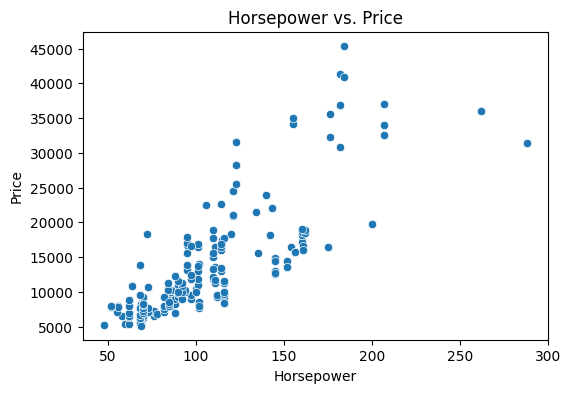

In [7]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x='horsepower', y='price', data=df)
plt.title('Horsepower vs. Price')
plt.xlabel('Horsepower')
plt.ylabel('Price')
plt.show()

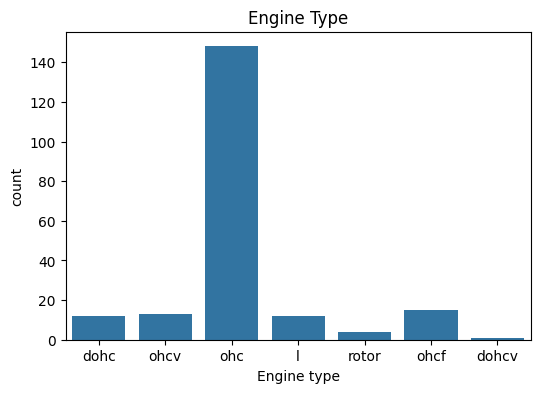

In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(x='enginetype', data=df)
plt.title('Engine Type')
plt.xlabel('Engine type')
plt.show()

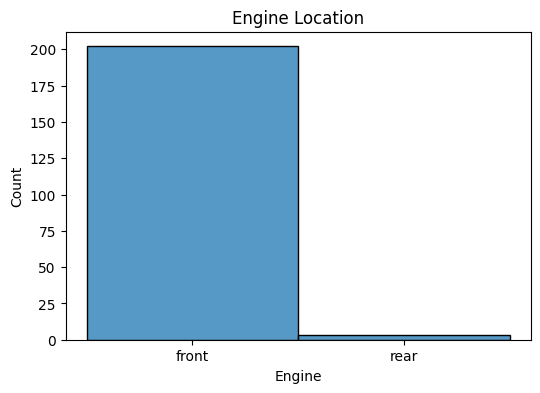

In [37]:
plt.figure(figsize=(6, 4))
sns.histplot(x='enginelocation', data=df)
plt.title('Engine Location')
plt.xlabel('Engine')
plt.show()

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error,root_mean_squared_error

In [17]:
X=df[["horsepower","enginesize","curbweight"]]
y=df["price"]
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [31]:
from sklearn import linear_model
linear_model = linear_model.LinearRegression()

In [32]:
linear_model.fit(x_train,y_train)

LinearRegression()

In [33]:
x_test

,horsepower,enginesize,curbweight
15,182,209,3230
9,160,131,3053
100,97,120,2302
132,110,121,2658
68,123,183,3750
95,69,97,2028
159,56,110,2275
162,70,98,2140
147,94,108,2455
182,52,97,2261


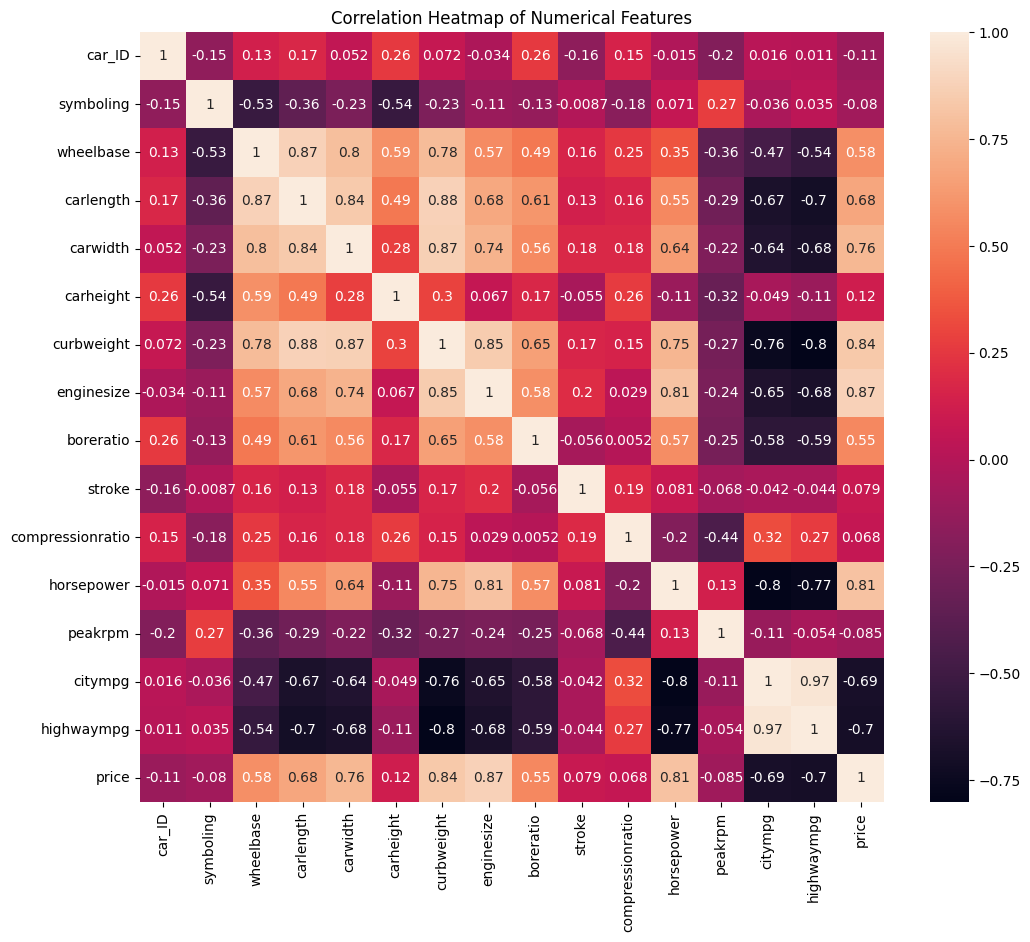

In [43]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [34]:
linear_model.predict(x_test)

array([26675.83675306, 18673.27218441, 11226.32113258, 13520.42081085,
       23691.11924683,  6763.18184184,  8125.47500865,  7371.76748858,
       10783.43332747,  6839.77001664, 14699.30073444,  7644.32782622,
       15587.23862756, 11589.45815103, 37333.21655296,  5942.06311984,
         533.6441619 , 18871.87993969, 11335.67010545, 10293.67647078,
       11141.50463373, 22308.23360232,  6678.00673633,  4440.45977852,
        5999.04386711, 27314.6500444 , 15267.54763564, 16891.97691957,
        6801.51063932, 16372.40877595, 22690.31175707,  5905.35125105,
        7113.22082062, 20363.26834721,  9116.73524973, 22605.13665156,
       11933.36667203,  7886.95109964,  5766.07306912, 19267.94418032,
        9434.36096271])

In [29]:

mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression MAE: {mae_lr}")
print(f"Linear Regression MSE: {mse_lr}")
print(f"Linear Regression RMSE: {rmse_lr}")
print(f"Linear Regression R^2: {r2_lr:}")


Linear Regression MAE: 2722.101702438692
Linear Regression MSE: 14145734.532358827
Linear Regression RMSE: 3761.0815641725753
Linear Regression R^2: 0.8208130980062114


In [23]:
from sklearn.linear_model import Ridge
ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(x_train, y_train)

y_pred_ridge = ridge_model.predict(x_test)

# Calculate metrics for Ridge Regression
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"Ridge Regression MAE: {mae_ridge:.2f}")
print(f"Ridge Regression MSE: {mse_ridge:.2f}")
print(f"Ridge Regression RMSE: {rmse_ridge:.2f}")
print(f"Ridge Regression R^2: {r2_ridge:.2f}")


Ridge Regression MAE: 2722.10
Ridge Regression MSE: 14145753.79
Ridge Regression RMSE: 3761.08
Ridge Regression R^2: 0.82


### 3. Lasso Regression

In [24]:
from sklearn.linear_model import Lasso
lasso_model = Lasso(alpha=1.0, random_state=42)

# Make predictions on the test set
y_pred_lasso = lasso_model.predict(x_test)

# Calculate metrics for Lasso Regression
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print(f"Lasso Regression MAE: {mae_lasso:.2f}")
print(f"Lasso Regression MSE: {mse_lasso:.2f}")
print(f"Lasso Regression RMSE: {rmse_lasso:.2f}")
print(f"Lasso Regression R^2: {r2_lasso:.2f}")


Lasso Regression MAE: 2722.11
Lasso Regression MSE: 14145765.16
Lasso Regression RMSE: 3761.09
Lasso Regression R^2: 0.82


### 4. Model Comparison

In [25]:
metrics_data = {
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression'],
    'MAE': [mae_lr, mae_ridge, mae_lasso],
    'MSE': [mse_lr, mse_ridge, mse_lasso],
    'RMSE': [rmse_lr, rmse_ridge, rmse_lasso],
    'R^2': [r2_lr, r2_ridge, r2_lasso]
}

comparison_df = pd.DataFrame(metrics_data)
display(comparison_df)


,Model,MAE,MSE,RMSE,R^2
0,Linear Regression,2722.101702,1.414573e+07,3761.081564,0.820813
1,Ridge Regression,2722.104667,1.414575e+07,3761.084125,0.820813
2,Lasso Regression,2722.105146,1.414577e+07,3761.085635,0.820813
